In [7]:
from common import *
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC

results = {}


## Classifier-Specific Helper Functions


In [8]:
def plot_coefficients(model, feature_names, title, path):
    values = model.coef_[0]
    order = np.argsort(np.abs(values))[-15:]

    plt.figure(figsize=(10, 8))
    plt.barh(np.array(feature_names)[order], values[order])
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()

    full_path = common_path / path
    os.makedirs(full_path.parent, exist_ok=True)
    plt.savefig(full_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_support_vectors(model, class_names, title, path):
    plt.figure(figsize=(8, 8))
    plt.bar(class_names, model.n_support_)
    plt.xlabel("Class")
    plt.ylabel("Number of Support Vectors")
    plt.title(title)
    plt.tight_layout()

    full_path = common_path / path
    os.makedirs(full_path.parent, exist_ok=True)
    plt.savefig(full_path, dpi=200, bbox_inches="tight")
    plt.show()


## Logistic Regression Classifier


In [9]:
def run_logistic_regression():
    out_path = common_path / "logistic_regression"
    os.makedirs(out_path, exist_ok=True)

    for scaled in [True, False]:
        scale_tag = "scaled" if scaled else "unscaled"
        label = f"Logistic Regression ({scale_tag.capitalize()})"

        train_x, test_x, train_y, test_y, class_names, feature_names = data_preprocess(scaler=scaled)

        print("\n")
        print("=" * 80)
        print(f"{label} Classifier Trained on Breast Cancer Dataset")
        print("=" * 80)

        model, predicted_y, metrics = train_and_eval_model(
            LogisticRegression(max_iter=10000, random_state=42),
            train_x,
            test_x,
            train_y,
            test_y
        )
        results[label] = metrics

        plot_cm(test_y, predicted_y, class_names, title=label, path=out_path / f"confusion_matrix_{scale_tag}.png")
        plot_coefficients(model, feature_names, title=f"{label}: Largest Coefficients", path=out_path / f"coefficients_{scale_tag}.png")


## Perceptron Classifier


In [10]:
def run_perceptron():
    out_path = common_path / "perceptron"
    os.makedirs(out_path, exist_ok=True)

    for scaled in [True]:
        scale_tag = "scaled" if scaled else "unscaled"
        label = f"Perceptron ({scale_tag.capitalize()})"

        train_x, test_x, train_y, test_y, class_names, feature_names = data_preprocess(scaler=scaled)

        print("\n")
        print("=" * 80)
        print(f"{label} Classifier Trained on Breast Cancer Dataset")
        print("=" * 80)

        model, predicted_y, metrics = train_and_eval_model(
            Perceptron(max_iter=10000, random_state=42),
            train_x,
            test_x,
            train_y,
            test_y
        )
        results[label] = metrics

        plot_cm(test_y, predicted_y, class_names, title=label, path=out_path / f"confusion_matrix_{scale_tag}.png")
        plot_coefficients(model, feature_names, title=f"{label}: Largest Weights", path=out_path / f"weights_{scale_tag}.png")


## Support Vector Machine Classifier


In [11]:
def run_svm():
    out_path = common_path / "svm"
    os.makedirs(out_path, exist_ok=True)

    for scaled in [True, False]:
        scale_tag = "scaled" if scaled else "unscaled"
        label = f"SVM ({scale_tag.capitalize()})"

        train_x, test_x, train_y, test_y, class_names, feature_names = data_preprocess(scaler=scaled)

        print("\n")
        print("=" * 80)
        print(f"{label} Classifier Trained on Breast Cancer Dataset")
        print("=" * 80)

        model, predicted_y, metrics = train_and_eval_model(
            SVC(kernel="rbf", random_state=42),
            train_x,
            test_x,
            train_y,
            test_y
        )
        results[label] = metrics

        plot_cm(test_y, predicted_y, class_names, title=label, path=out_path / f"confusion_matrix_{scale_tag}.png")
        plot_support_vectors(model, class_names, title=f"{label}: Support Vectors by Class", path=out_path / f"support_vectors_{scale_tag}.png")




Logistic Regression (Scaled) Classifier Trained on Breast Cancer Dataset


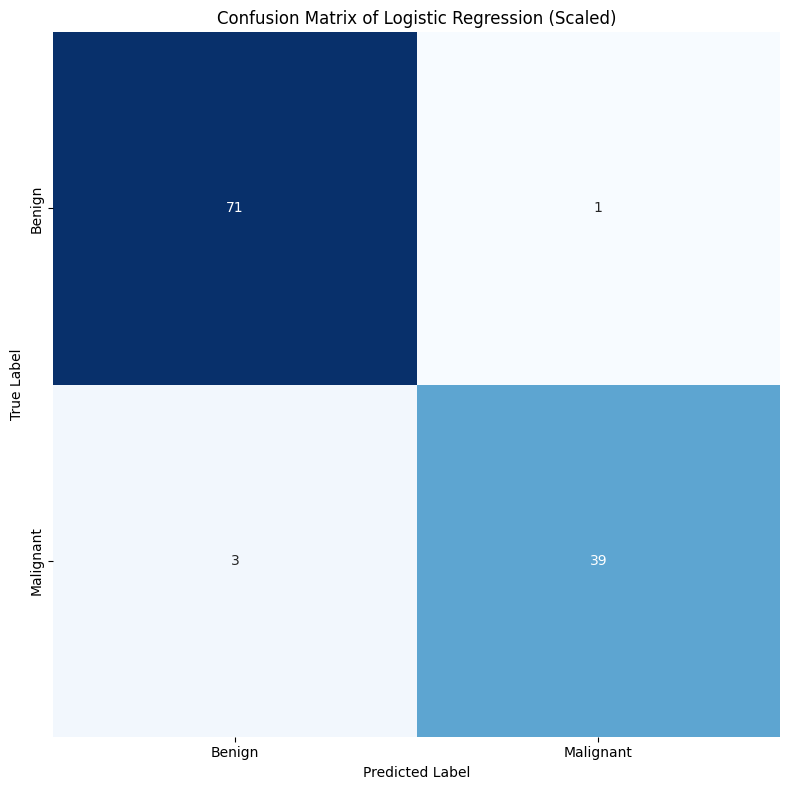

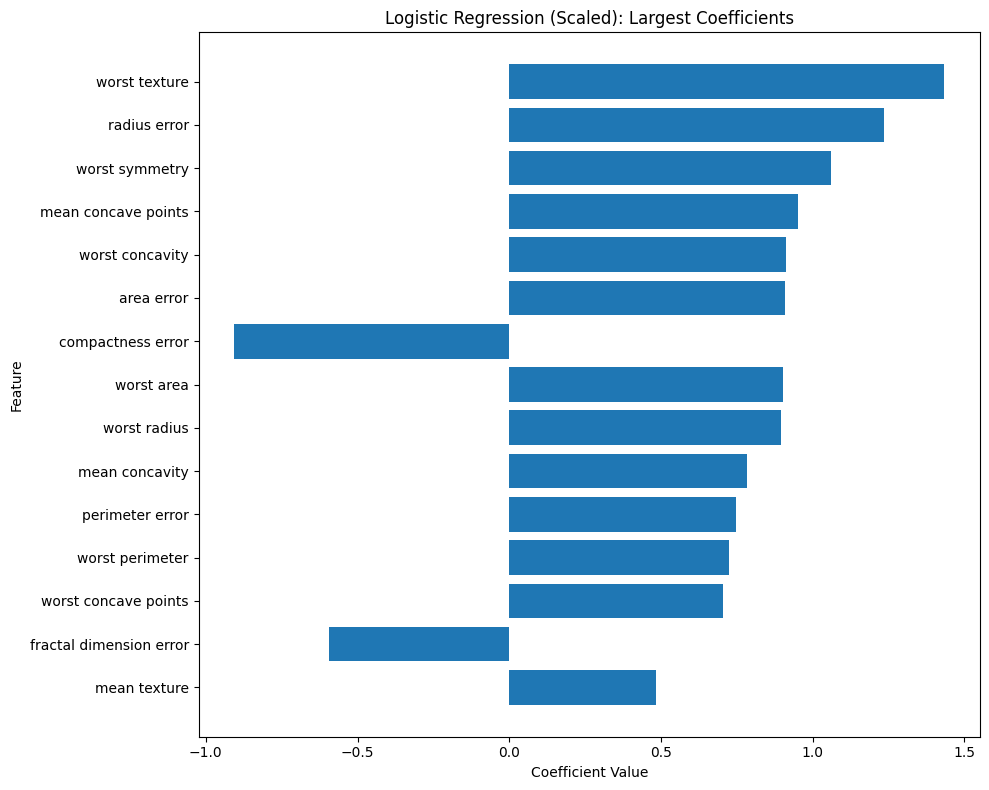



Logistic Regression (Unscaled) Classifier Trained on Breast Cancer Dataset


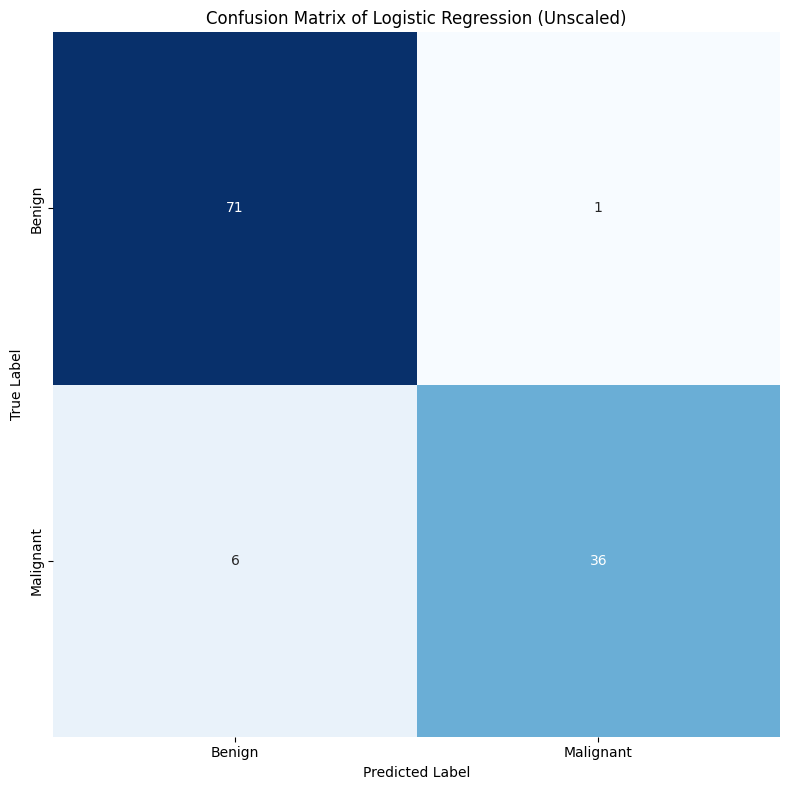

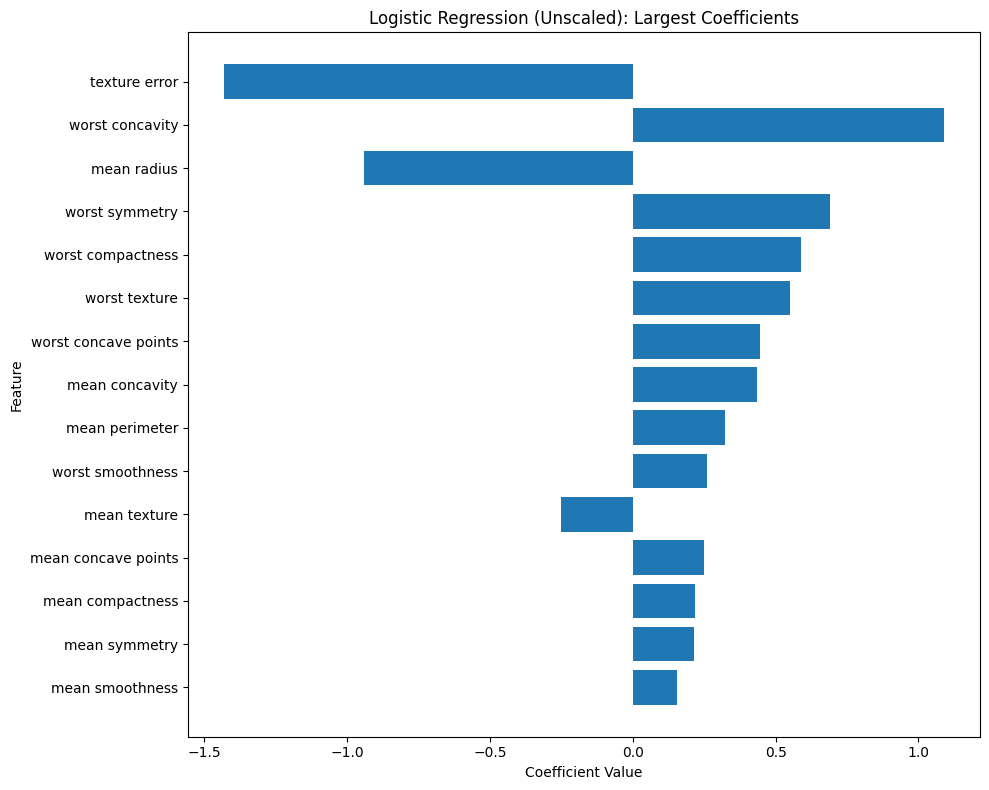



Perceptron (Scaled) Classifier Trained on Breast Cancer Dataset


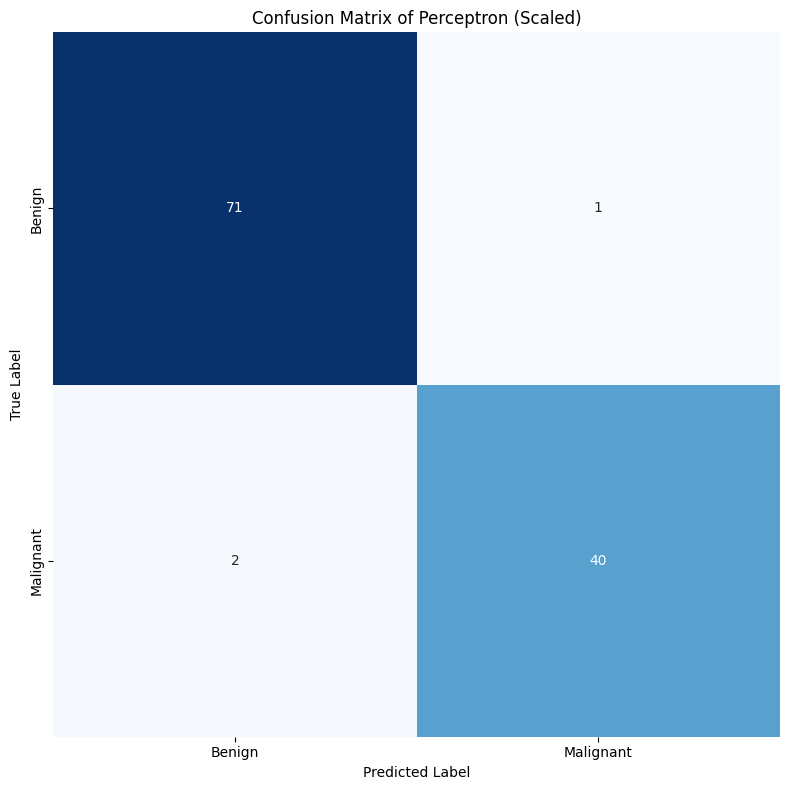

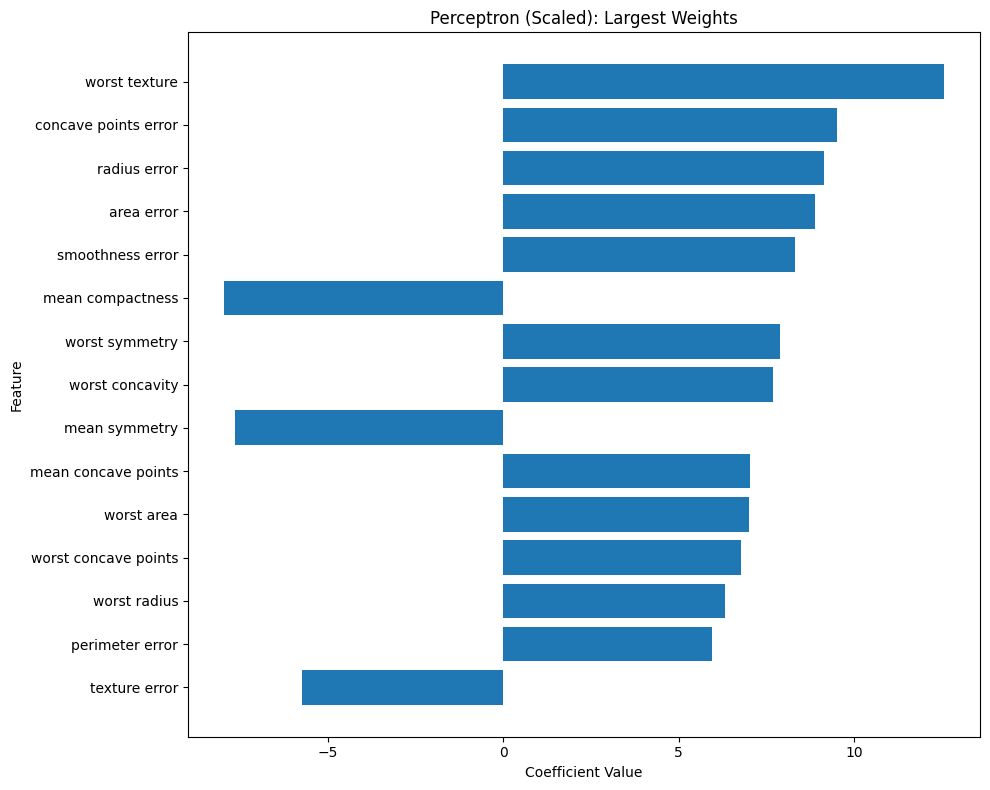



SVM (Scaled) Classifier Trained on Breast Cancer Dataset


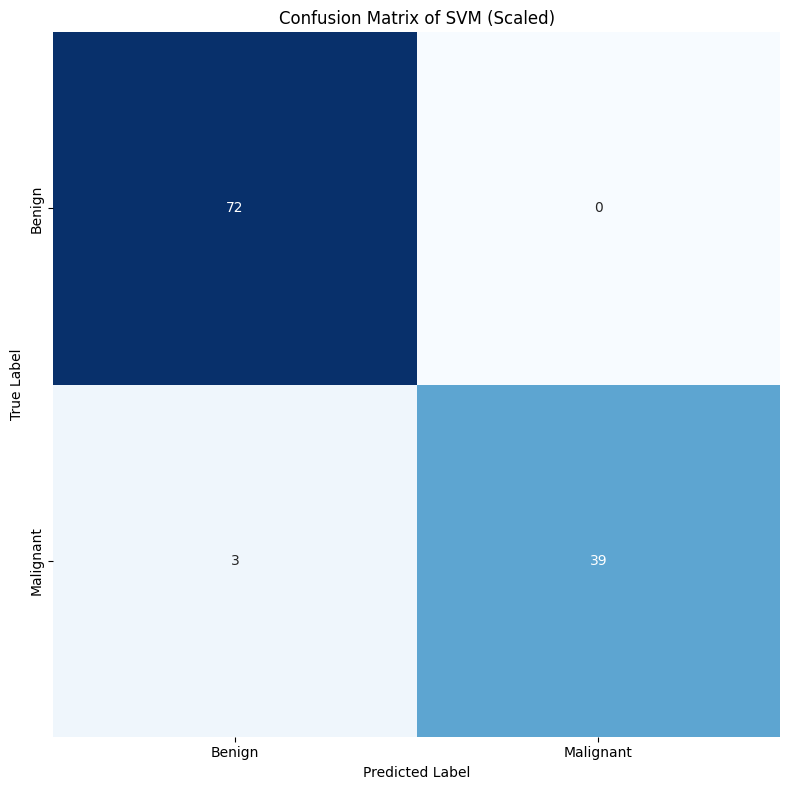

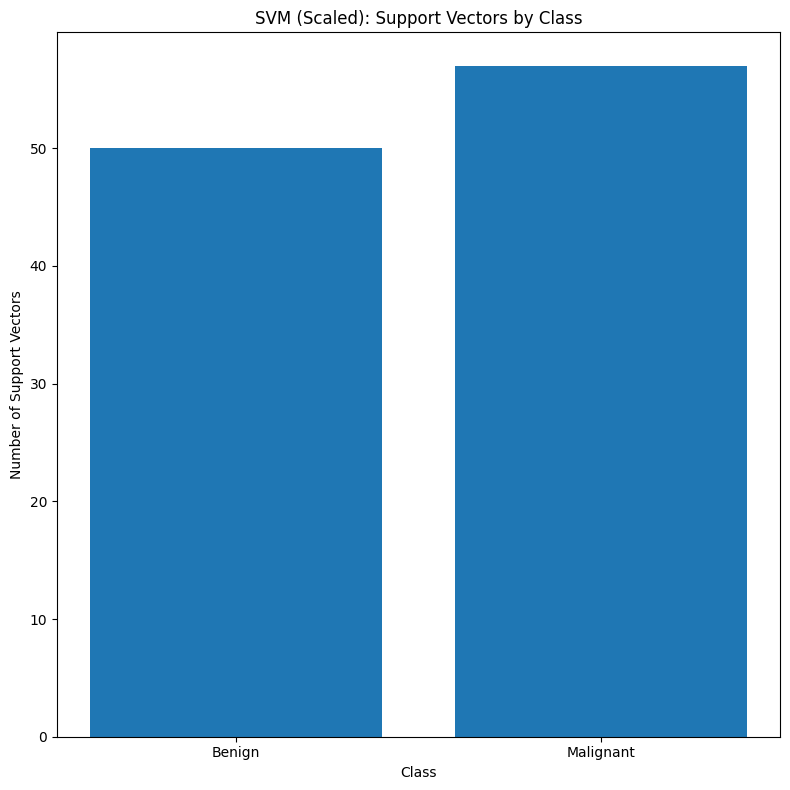



SVM (Unscaled) Classifier Trained on Breast Cancer Dataset


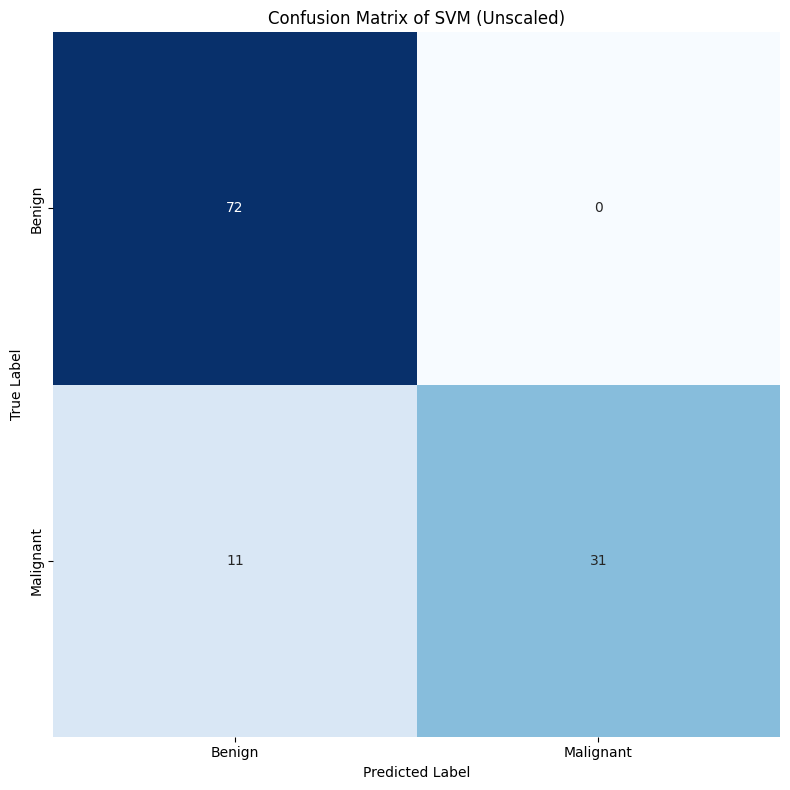

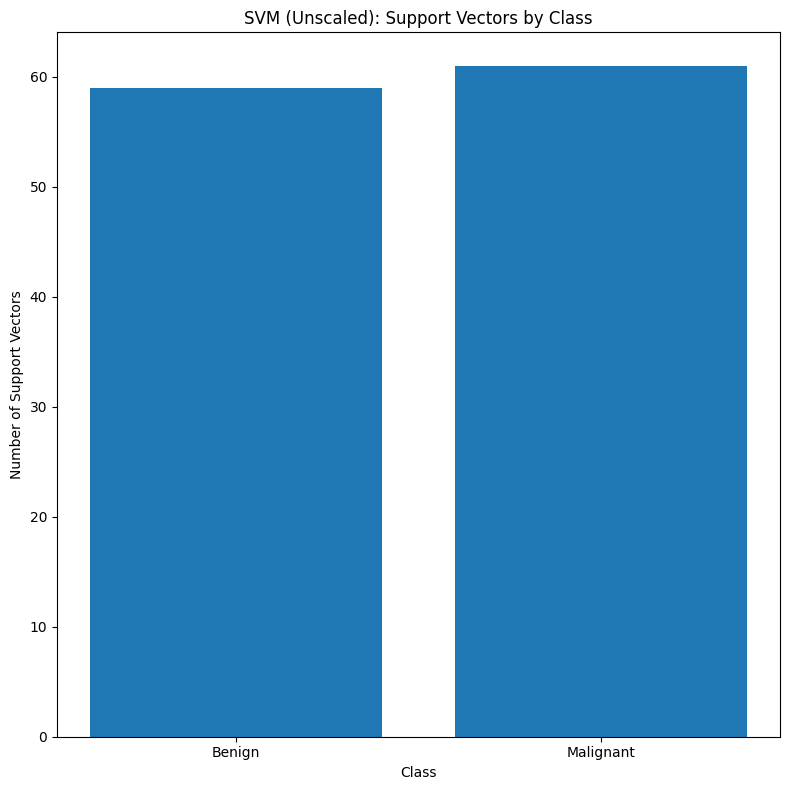



Model Metrics Results


Logistic Regression (Scaled)
----------------------------------------------------------------------
Training Accuracy:    0.9868
Testing Accuracy:    0.9649
Model Precision:    0.9750
Model Recall:    0.9286
F1 Score  :    0.9512


Logistic Regression (Unscaled)
----------------------------------------------------------------------
Training Accuracy:    0.9648
Testing Accuracy:    0.9386
Model Precision:    0.9730
Model Recall:    0.8571
F1 Score  :    0.9114


Perceptron (Scaled)
----------------------------------------------------------------------
Training Accuracy:    0.9780
Testing Accuracy:    0.9737
Model Precision:    0.9756
Model Recall:    0.9524
F1 Score  :    0.9639


SVM (Scaled)
----------------------------------------------------------------------
Training Accuracy:    0.9868
Testing Accuracy:    0.9737
Model Precision:    1.0000
Model Recall:    0.9286
F1 Score  :    0.9630


SVM (Unscaled)
------------------------------------------------------

In [12]:
def main():
    run_logistic_regression()
    run_perceptron()
    run_svm()
    print_metrics(results=results)

if __name__ == "__main__":
    main()
